**A_STAR**

Shortest Path:
A->B->E->G
Total Cost: 8


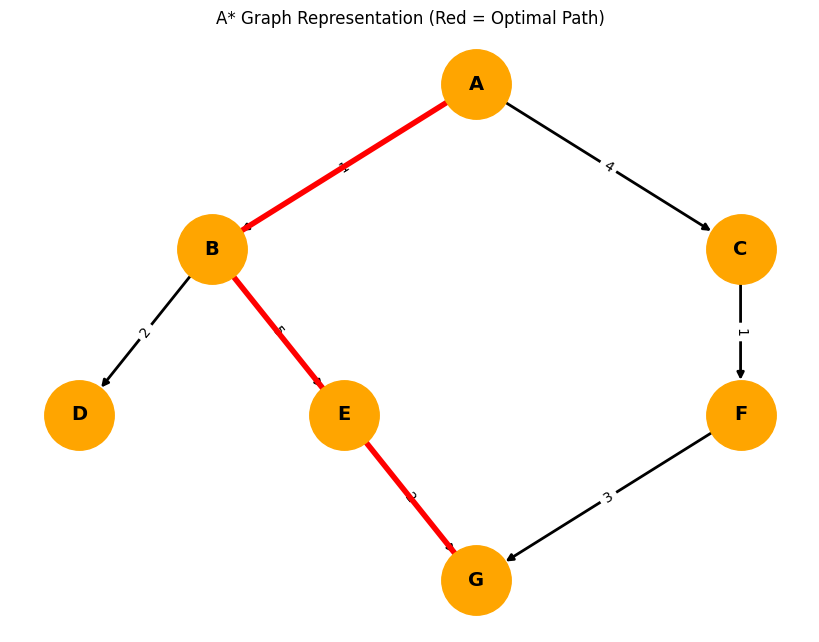

In [1]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx

graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 2), ('E', 5)],
    'C': [('F', 1)],
    'D': [],
    'E': [('G', 2)],
    'F': [('G', 3)],
    'G': []
}

heuristic = {
    'A': 7,
    'B': 6,
    'C': 2,
    'D': 5,
    'E': 2,
    'F': 1,
    'G': 0
}

def astar(graph, heuristic, start, goal):
    pq = [(heuristic[start], 0, start, [start])]
    visited = set()
    while pq:
        f, g, node, path = heapq.heappop(pq)
        if node == goal:
            return path, g
        if node in visited:
            continue
        visited.add(node)
        for neighbor, cost in graph[node]:
            new_g = g + cost
            new_f = new_g + heuristic[neighbor]
            heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))
    return None, float('inf')

path, cost = astar(graph, heuristic, 'A', 'G')
print('Shortest Path:')
print("->".join(path))
print("Total Cost:", cost)

G = nx.DiGraph()
for node in graph:
    for neighbor, weight in graph[node]:
        G.add_edge(node, neighbor, weight=weight)

pos = {
    'A': (0, 3),
    'B': (-1, 2),
    'C': (1, 2),
    'D': (-1.5, 1),
    'E': (-0.5, 1),
    'F': (1, 1),
    'G': (0, 0),
}

plt.figure(figsize=(8, 6))
nx.draw(
    G, pos,
    with_labels=True,
    node_color='orange',
    node_size=2500,
    font_size=14,
    font_weight='bold',
    edge_color='black',
    arrows=True,
    width=2
)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

path_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_edges(
    G, pos,
    edgelist=path_edges,
    edge_color='red',
    width=4,
    arrows=True
)

plt.title("A* Graph Representation (Red = Optimal Path)")
plt.axis('off')
plt.show()

**AO STAR**

Optimal Solution path:
A->C->F
Total cost: 6


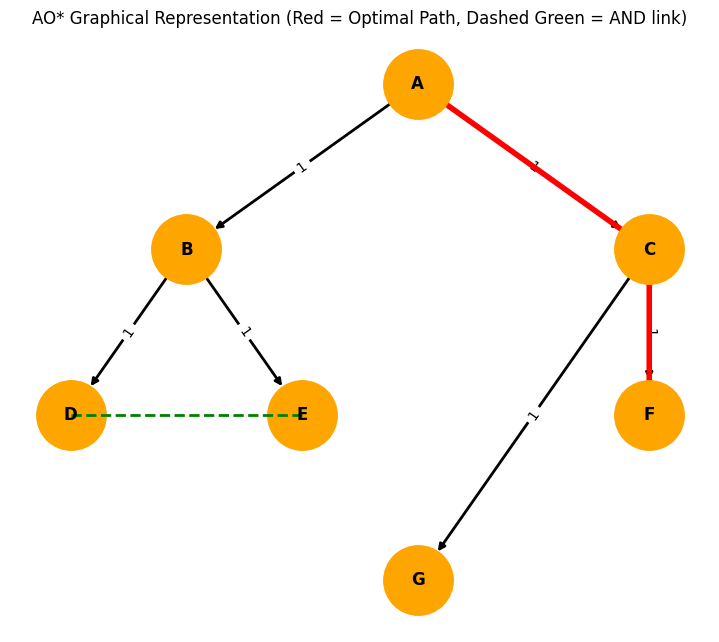

In [2]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx

graph = {
    'A': {'type': 'OR',  'children': [('B', 1), ('C', 1)]},
    'B': {'type': 'AND', 'children': [('D', 1), ('E', 1)]},
    'C': {'type': 'OR', 'children': [('F', 1), ('G', 1)]},
    'D': {'type': 'LEAF', 'cost': 2},
    'E': {'type': 'LEAF', 'cost': 3},
    'F': {'type': 'LEAF', 'cost': 4},
    'G': {'type': 'LEAF', 'cost': 6}
}

def ao_star(node):
    info = graph[node]

    if info['type'] == 'LEAF':
        return info['cost'], [node]

    if info['type'] == 'OR':
        # Push every option onto a heap, pop the cheapest
        heap = []
        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total_cost = edge_cost + child_cost
            heapq.heappush(heap, (total_cost, child, child_path))
        min_cost, _, min_child_path = heapq.heappop(heap)
        return min_cost, [node] + min_child_path

    if info['type'] == 'AND':
        # All children required; cost sums, path includes both branches
        total_cost = 0
        full_path = [node]
        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total_cost += edge_cost + child_cost
            full_path += child_path
        return total_cost, full_path

cost, path = ao_star('A')
print("Optimal Solution path:")
print("->".join(path))
print("Total cost:", cost)

# ---------- Visualization ----------
G = nx.DiGraph()
for node, info in graph.items():
    if 'children' in info:
        for child, weight in info['children']:
            G.add_edge(node, child, weight=weight)

pos = {
    'A': (0, 3),
    'B': (-1, 2),
    'C': (1, 2),
    'D': (-1.5, 1),
    'E': (-0.5, 1),
    'F': (1, 1),
    'G': (0, 0)
}

plt.figure(figsize=(7, 6))
nx.draw(G, pos, with_labels=True,
        node_color='orange',
        node_size=2500,
        font_weight='bold',
        edge_color='black',
        arrows=True,
        width=2)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

path_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=4, arrows=True)

# Mark AND-node children with a dashed green arc between them
for node, info in graph.items():
    if info.get('type') == 'AND':
        children = [c for c, _ in info['children']]
        if len(children) > 1:
            x_vals = [pos[c][0] for c in children]
            y_vals = [pos[c][1] for c in children]
            plt.plot(x_vals, y_vals, linestyle='--', color='green', linewidth=2)

plt.title("AO* Graphical Representation (Red = Optimal Path, Dashed Green = AND link)")
plt.axis('off')
plt.show()